<a href="https://colab.research.google.com/github/ahmedtayel714/Advanced-AI-and-Uncertainty--W1/blob/main/W01_UncertaintyDemo_Team01_MyBuild.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced AI and Uncertainty: My Demo Notebook (CS405, Presentation 1)

**Author:** Ahmed Ayman Tayel &nbsp;|&nbsp; **Team:** Team 01 &nbsp;|&nbsp; **Registration ID:** 232611000001

**Dataset (public, real):** Pima Indians Diabetes Database, 768 patients, 8 measurements and an outcome (1 = diabetes, 0 = no diabetes). Collected by the U.S. National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK); J. W. Smith et al., *Proc. Symp. Computer Applications in Medical Care*, 1988.




In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(405)
os.makedirs("figures",exist_ok=True)

# colour tokens, identical to the slide design
CRISP, FUZZY, PROB = "#374151", "#0072B2", "#009E73"
WARM, HOT = "#E69F00", "#D55E00"
ALEA, EPIS, MISS = "#56B4E9", "#CC79A7", "#9CA3AF"

In [2]:
temp=np.random.default_rng(405)

print(temp.uniform(0,10,3))

[8.87646791 2.04477189 6.97190899]


## Step 2. Load the data safely




  - `https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv`
  - `https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv`



In [3]:

URLs =[
    " https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv" ,
    "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
]
for url in URLs :
    try:
        df=pd.read_csv(url)
        print("Loaded from :",url)
        break
    except Exception as err:
        print("Could not load", url, "->", err)
else:
        raise RuntimeError("The dataset could not be downloaded. Check the internet connection.")

assert df.shape == (768, 9), df.shape
print("Dataset: Pima Indians Diabetes Database (NIDDK; Smith et al., 1988):",
      df.shape[0], "patients,", df.shape[1] - 1, "predictors + Outcome")
df.head()

Loaded from :  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Dataset: Pima Indians Diabetes Database (NIDDK; Smith et al., 1988): 768 patients, 8 predictors + Outcome


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#  Missing data: the visible count and the hidden count


In [4]:
print("Missing values (Nan): ",df.isna().sum().sum())

Missing values (Nan):  0


## Find the hidden zeros




In [5]:
cols=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zeros=(df[cols] == 0).sum()
print(zeros.to_string())
print("\n rows with at least one impossible zero :",(df[cols]==0).any(axis=1).sum(),"of",len(df))
print("Pregnancies == 0 is legitimate (", int((df['Pregnancies'] == 0).sum()), "patients), so it is NOT recoded.")

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11

 rows with at least one impossible zero : 376 of 768
Pregnancies == 0 is legitimate ( 111 patients), so it is NOT recoded.


##  Recode the zeros as real missing values



In [17]:
df[cols]=df[cols].replace(0,np.nan)
df[cols].isna().sum()




,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


##  Bar chart of how much is missing



Text(0.5, 1.0, 'How much is missing once zeros are recoded')

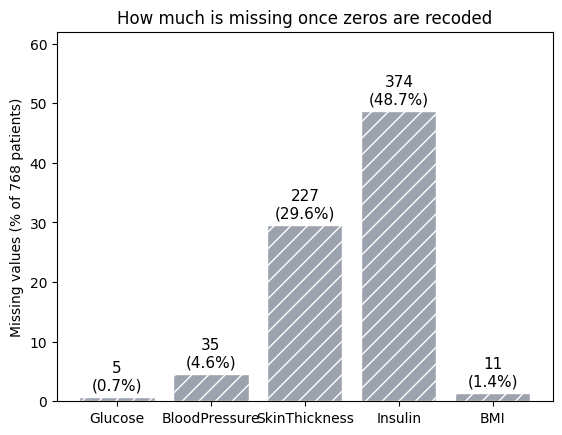

In [7]:
missing = df[cols].isna().sum()
pct=100 * missing / len(df)
fig=plt.bar(cols, pct, color=MISS, hatch="//", edgecolor="white")
for b, m, p in zip(fig,missing, pct):
    plt.text(b.get_x() + b.get_width() / 2, p + 1.2, f"{m}\n({p:.1f}%)", ha="center", fontsize=11)
plt.ylim(0, 62)
plt.ylabel("Missing values (% of 768 patients)")
plt.title("How much is missing once zeros are recoded")

##  Heatmap: where are the gaps?



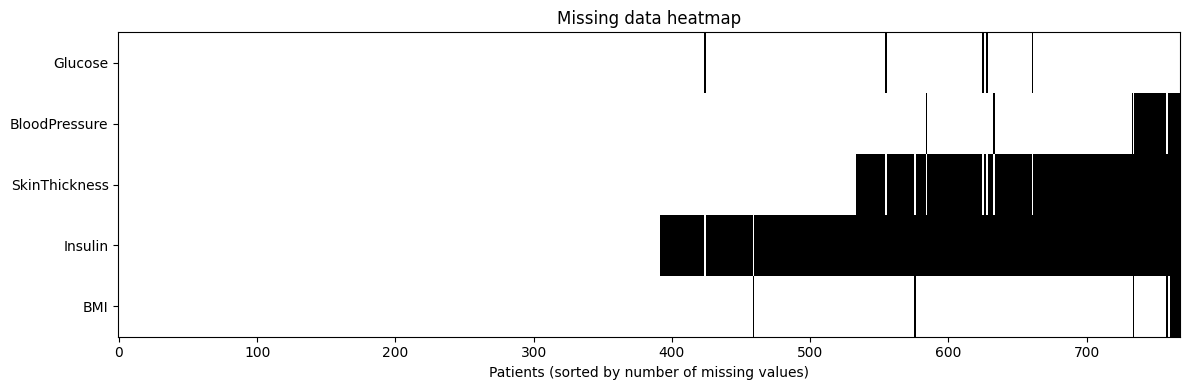

In [8]:
order = df[cols].isna().sum(axis=1).sort_values(kind="stable").index
heat_data = df.loc[order, cols].isna().to_numpy().T

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(heat_data, aspect="auto", cmap="Greys", interpolation="nearest")
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols)
ax.set_xlabel("Patients (sorted by number of missing values)")
ax.set_title("Missing data heatmap")
plt.tight_layout()
plt.savefig("figures/fig_missing_heatmap.png")
plt.show()


##  Does missingness relate to the outcome?



In [9]:
rate = (df[cols].isna().groupby(df["Outcome"]).mean() * 100).round(1)
rate.index = ["Outcome 0 (no diabetes)", "Outcome 1 (diabetes)"]
print("Percent missing by outcome group:")
print(rate.to_string())


Percent missing by outcome group:
                         Glucose  BloodPressure  SkinThickness  Insulin  BMI
Outcome 0 (no diabetes)      0.6            3.8           27.8     47.2  1.8
Outcome 1 (diabetes)         0.7            6.0           32.8     51.5  0.7


## Three strategies for Insulin, and the price of each



In [10]:

ins = df["Insulin"]
complete_rows = df.dropna(subset=cols)

table = pd.DataFrame({
    "rows kept": [len(complete_rows), int(ins.notna().sum()), len(ins), len(ins)],
    "mean Insulin": [complete_rows["Insulin"].mean(), ins.mean(),
                     ins.fillna(ins.mean()).mean(), ins.fillna(ins.median()).mean()],
    "sd Insulin": [complete_rows["Insulin"].std(), ins.std(),
                   ins.fillna(ins.mean()).std(), ins.fillna(ins.median()).std()],
}, index=["delete rows with any missing value", "delete only rows missing Insulin",
          "mean imputation", "median imputation"]).round(1)
print(table.to_string())


                                    rows kept  mean Insulin  sd Insulin
delete rows with any missing value        392         156.1       118.8
delete only rows missing Insulin          394         155.5       118.8
mean imputation                           768         155.5        85.0
median imputation                         768         140.7        86.4


##  A missing-value indicator column



In [11]:
df["Insulin_missing"] = ins.isna().astype(int)
print("\nIndicator column 'Insulin_missing' flags", int(df["Insulin_missing"].sum()), "patients.")
print("Deleting all incomplete rows keeps", len(complete_rows), "of 768 patients (",
      round(100 * len(complete_rows) / 768, 1), "% ).")
print("Mean imputation shrinks the spread of Insulin from",
      round(ins.std(), 1), "to", round(ins.fillna(ins.mean()).std(), 1), ".")


Indicator column 'Insulin_missing' flags 374 patients.
Deleting all incomplete rows keeps 392 of 768 patients ( 51.0 % ).
Mean imputation shrinks the spread of Insulin from 118.8 to 85.0 .


## The crisp and the fuzzy definition as arrays



In [12]:
bmi = np.linspace(15,60,451)
crisp = (bmi >= 30).astype(float)
fuzzy = np.clip((bmi-27) / 6,0,1)

##  Two panels and the numbers



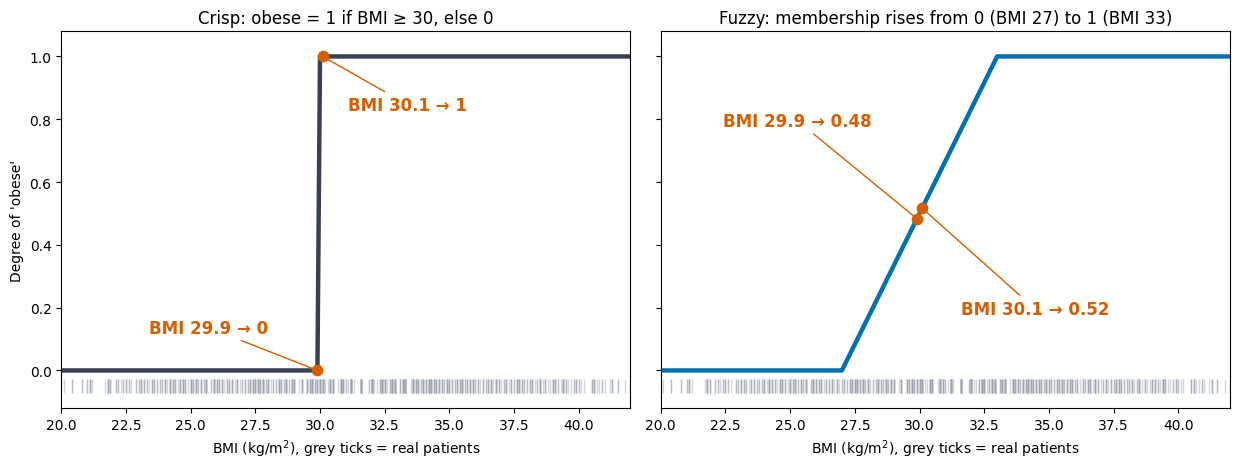

BMI 29.9: crisp = 0, fuzzy = 0.48
BMI 30.1: crisp = 1, fuzzy = 0.52
32.2% of the 757 patients with a recorded BMI fall inside the fuzzy ramp (27 to 33).


In [13]:
patients = df["BMI"].dropna().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

for ax, curve, colour, title in [
    (axes[0], crisp, CRISP, "Crisp: obese = 1 if BMI ≥ 30, else 0"),
    (axes[1], fuzzy, FUZZY, "Fuzzy: membership rises from 0 (BMI 27) to 1 (BMI 33)"),
]:
    ax.plot(bmi, curve, color=colour, lw=3.2)
    ax.plot(patients, np.full_like(patients, -0.05), "|", color=MISS, alpha=0.45, ms=10)  # real patients
    ax.set_xlim(20, 42)
    ax.set_ylim(-0.12, 1.08)
    ax.set_xlabel("BMI (kg/m$^2$), grey ticks = real patients")
    ax.set_title(title)
axes[0].set_ylabel("Degree of 'obese'")

for b, dy in [(29.9, 0.22), (30.1, -0.22)]:
    c = float(b >= 30)
    f = float(np.clip((b - 27) / 6, 0, 1))
    axes[0].scatter([b], [c], color=HOT, zorder=5, s=55)
    axes[1].scatter([b], [f], color=HOT, zorder=5, s=55)
    axes[0].annotate(f"BMI {b} → {c:.0f}", (b, c), xytext=(b - 6.5 if b < 30 else b + 1.0, 0.12 if b < 30 else 0.83),
                     arrowprops=dict(arrowstyle="-", color=HOT), color=HOT, fontsize=12, fontweight="bold")
    axes[1].annotate(f"BMI {b} → {f:.2f}", (b, f), xytext=(b - 7.5 if b < 30 else b + 1.5, 0.78 if b < 30 else 0.18),
                     arrowprops=dict(arrowstyle="-", color=HOT), color=HOT, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_bmi_crisp_vs_fuzzy.png", dpi=200, bbox_inches="tight")
plt.show()

for b in (29.9, 30.1):
    print(f"BMI {b}: crisp = {float(b >= 30):.0f}, fuzzy = {np.clip((b - 27) / 6, 0, 1):.2f}")
share = ((patients > 27) & (patients < 33)).mean() * 100
print(f"{share:.1f}% of the {len(patients)} patients with a recorded BMI fall inside the fuzzy ramp (27 to 33).")


## The data generator


In [14]:
TRUE_A, TRUE_B, SIGMA = 2.0, 1.5, 3.0   # true line y = 2 + 1.5 x; noise sd = 3
X0 = 5.0                                # where we ask each fitted model for a prediction
REPEATS = 300


def draw(n):
    x = rng.uniform(0, 10, n)
    y = TRUE_A + TRUE_B * x + rng.normal(0, SIGMA, n)   # the noise term is the aleatoric part
    return x.reshape(-1, 1), y



##  The simulation loop and the results table



In [15]:

rows = []
for n in (20, 200, 2000):
    preds, noise_sd = [], []
    for _ in range(REPEATS):
        x, y = draw(n)
        model = LinearRegression().fit(x, y)
        preds.append(model.predict([[X0]])[0])
        noise_sd.append(np.std(y - model.predict(x), ddof=2))
    rows.append({"samples n": n,
                 "epistemic sd (spread of predictions)": np.std(preds),
                 "aleatoric sd (noise left in data)": np.mean(noise_sd),
                 "theory: sigma / sqrt(n)": SIGMA / np.sqrt(n)})

res = pd.DataFrame(rows).round(3)
res

,samples n,epistemic sd (spread of predictions),aleatoric sd (noise left in data),theory: sigma / sqrt(n)
0,20,0.677,2.953,0.671
1,200,0.220,2.997,0.212
2,2000,0.066,3.003,0.067


##  The 2 by 2 figure




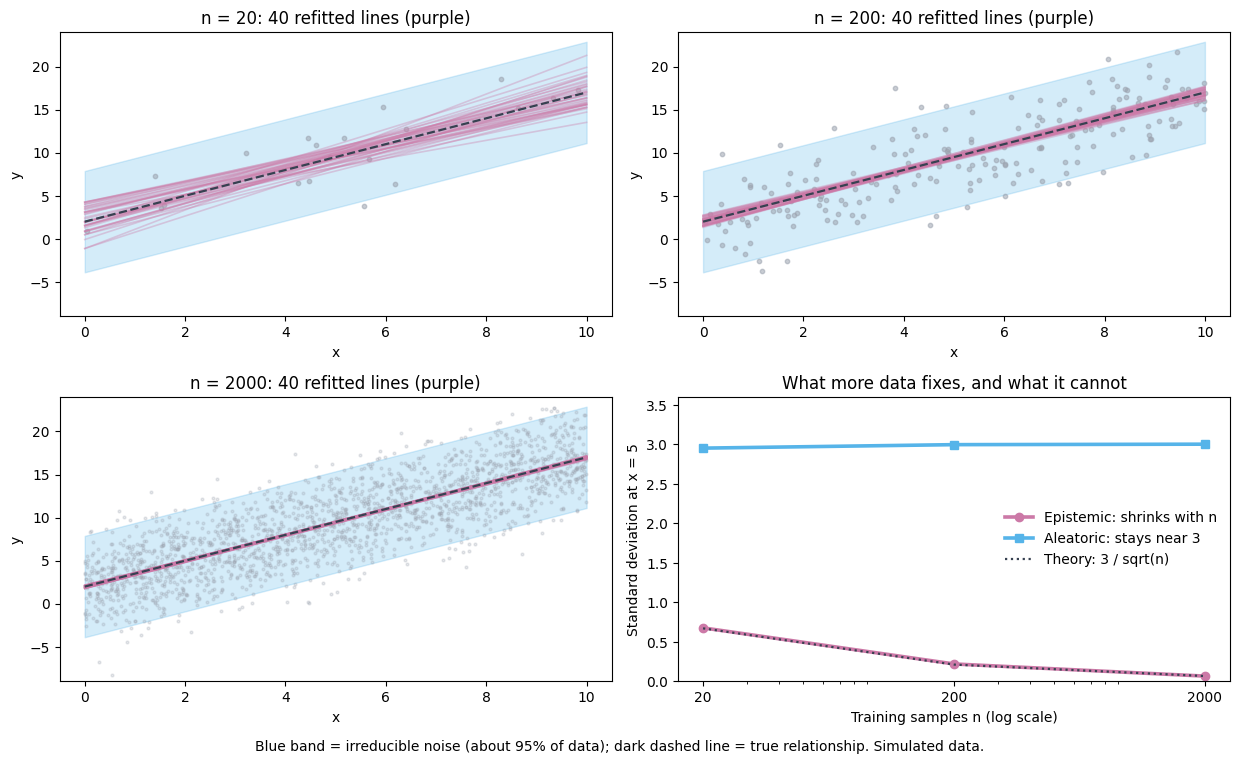

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.6))
xs = np.array([[0.0], [10.0]])
true_line = TRUE_A + TRUE_B * xs.ravel()

for ax, n in zip(axes.ravel()[:3], (20, 200, 2000)):
    x, y = draw(n)
    ax.scatter(x, y, s=10 if n < 2000 else 4, color=MISS, alpha=0.55 if n < 2000 else 0.25, zorder=1)
    for _ in range(40):                                   # 40 refits on fresh samples
        xi, yi = draw(n)
        m = LinearRegression().fit(xi, yi)
        ax.plot(xs.ravel(), m.predict(xs), color=EPIS, alpha=0.35, lw=1.2, zorder=3)
    ax.fill_between(xs.ravel(), true_line - 1.96 * SIGMA, true_line + 1.96 * SIGMA,
                    color=ALEA, alpha=0.25, zorder=0)
    ax.plot(xs.ravel(), true_line, color=CRISP, ls="--", lw=1.6, zorder=4)
    ax.set_ylim(-9, 24)
    ax.set_title(f"n = {n}: 40 refitted lines (purple)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

ax = axes[1, 1]
ax.plot(res["samples n"], res["epistemic sd (spread of predictions)"], "o-", color=EPIS, lw=2.6, label="Epistemic: shrinks with n")
ax.plot(res["samples n"], res["aleatoric sd (noise left in data)"], "s-", color=ALEA, lw=2.6, label="Aleatoric: stays near 3")
ax.plot(res["samples n"], res["theory: sigma / sqrt(n)"], ":", color=CRISP, lw=1.6, label="Theory: 3 / sqrt(n)")
ax.set_xscale("log")
ax.set_xticks([20, 200, 2000])
ax.set_xticklabels(["20", "200", "2000"])
ax.set_ylim(0, 3.6)
ax.set_xlabel("Training samples n (log scale)")
ax.set_ylabel("Standard deviation at x = 5")
ax.set_title("What more data fixes, and what it cannot")
ax.legend(frameon=False, loc="center right")

fig.text(0.5, 0.005, "Blue band = irreducible noise (about 95% of data); dark dashed line = true relationship. Simulated data.", ha="center", fontsize=10)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig("figures/fig_epistemic_aleatoric_simulation.png", dpi=200, bbox_inches="tight")
plt.show()